In [1]:
###!/usr/bin/env python
################################################
# New style 
# ###############################################
import sys

rootdir_ = '../'
if ( rootdir_ not in sys.path ):
    sys.path.append(rootdir_)
    print( f" a path to {rootdir_} added in {__name__} ")


from Utils import GridUtils as GrU
from Utils import MakePressures as MkP
from Utils import utils as uti
from Utils import MyConstants as Co
from Utils import time_utils as tuti
from Utils import numerical_utils as nuti

import analysis_utils as auti
import file_utils as futi
import event_utils as euti
import event_io as eio


#from PyRegridding.Utils import MakePressures as MkP
#from Drivers import RegridField as RgF
import RegridField as RgF

# The usual
from datetime import date
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# for smoothing , nonlienar colors ...
from scipy.ndimage import uniform_filter
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors

# Some other useful packages 
import copy
import time
import cftime
import yaml
import numbers
import pickle

# Some other useful packages 
import importlib
from pathlib import Path


importlib.reload( auti )
importlib.reload( futi )
importlib.reload( euti )
importlib.reload( eio )

Rdair=Co.Rdair()


 a path to ../ added in __main__ 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
Using Flexible parallel/serial VertRegrid 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
 a path to /glade/work/juliob added in Utils.numerical_utils 


In [2]:
# This allow both dict.key and dict['key'] syntax
class AttrDict(dict):
    def __getattr__(self, key):
        try:
            return self[key]
        except KeyError:
            raise AttributeError(f"'AttrDict' object has no attribute '{key}'")

    def __setattr__(self, key, value):
        self[key] = value

    def __delattr__(self, key):
        try:
            del self[key]
        except KeyError:
            raise AttributeError(f"'AttrDict' object has no attribute '{key}'")



In [3]:
recalculate = False # False 
read_stored_El = not recalculate

print( f"Redoing A and Els ={recalculate}, Readin stored = {read_stored_El} ")


Redoing A and Els =False, Readin stored = True 


In [4]:
%%time
if recalculate == False and read_stored_El==True:
    
    #fEl1 = '/glade/derecho/scratch/juliob/archive/GW_event_analysis/PKL/cam77_dyamond1_prod1_2016-08-01-10800-x-2016-08-31-75600_60S-40S_ocean_EvZ10km_rho_epwp.pkl'
    #fEl2 = '/glade/derecho/scratch/juliob/archive/GW_event_analysis/PKL/cam77_dyamond1_prod1_2016-08-01-10800-x-2016-08-31-75600_35N-70N_ocean_EvZ10km_rho_epwp.pkl'
    #fEl1 = '/glade/derecho/scratch/juliob/archive/GW_event_analysis/PKL/cam77_dyamond1_prod1_2016-08-01-10800-x-2016-08-31-75600_60S-40S_ocean_EvZ10km_rho_epwp_ftp5X5.pkl'
    #fEl2 = '/glade/derecho/scratch/juliob/archive/GW_event_analysis/PKL/cam77_dyamond1_prod1_2016-08-01-10800-x-2016-08-31-75600_60S-40S_ocean_EvZ10km_rho_epwp_ftp5X5_test.pkl'
    #fEl1 = '/glade/derecho/scratch/juliob/archive/GW_event_analysis/PKL/c124_dyamond1_prod2_2016-08-01-10800-x-2016-08-31-75600_60S-40S_ocean_EvZ10km_rho_epwp.pkl'
    #fEl2 = '/glade/derecho/scratch/juliob/archive/GW_event_analysis/PKL/c124_dyamond1_prod2_2016-08-01-10800-x-2016-08-31-75600_35N-70N_ocean_EvZ10km_rho_epwp.pkl'


    fEl1 = '/glade/derecho/scratch/juliob/archive/GW_event_analysis/PKL/cam77_dyamond1_prod1_2016-08-01-10800-x-2016-08-31-75600_60S-40S_ocean_EvZ10km_rho_epwp_v2.pkl'
    fEl2 = '/glade/derecho/scratch/juliob/archive/GW_event_analysis/PKL/cam77_dyamond1_prod1_2016-08-01-10800-x-2016-08-31-75600_35N-70N_ocean_EvZ10km_rho_epwp_v2.pkl'
    
    print( f"Reading in stored = {read_stored_El} from \n {fEl1} ")
    with open(f'{fEl1}', 'rb') as f:
        El = pickle.load(f)
    
    print( f"Reading in stored = {read_stored_El} from \n {fEl2} ")
    with open(f'{fEl2}', 'rb') as f:
        El2 = pickle.load(f)


Reading in stored = True from 
 /glade/derecho/scratch/juliob/archive/GW_event_analysis/PKL/cam77_dyamond1_prod1_2016-08-01-10800-x-2016-08-31-75600_60S-40S_ocean_EvZ10km_rho_epwp_v2.pkl 
Reading in stored = True from 
 /glade/derecho/scratch/juliob/archive/GW_event_analysis/PKL/cam77_dyamond1_prod1_2016-08-01-10800-x-2016-08-31-75600_35N-70N_ocean_EvZ10km_rho_epwp_v2.pkl 
CPU times: user 0 ns, sys: 3min 26s, total: 3min 26s
Wall time: 5min 4s


In [5]:
import predictors as Predi
importlib.reload(Predi)

Eco=El[3]
zlev=Eco.zlevA
predictors,predictor_names,use_predictors,key_z,short_desc =Predi.probe_steer_launch(Eco=Eco,zlev=zlev,   zlev_steer=[1000,5000,10000],  zlev_launch=[1000,5000,10000] )

Created predictor set to explore steer and launch 


In [7]:
print(predictor_names[0])
print(predictors[0].shape)
print( Eco.zeta_4D.shape )

U_wv_src_mm t=-3, zsteer:1064 zlnch:4995
(702,)
(702, 4, 58, 11, 11)


In [8]:
%%time
importlib.reload( futi )
importlib.reload( nuti )
if recalculate == True and read_stored_El==False:
    nsteps=None
    start_date=None
    super_lat_range = [-90.,90.]  #[-85,-30]
    #super_lat_range = [-80.,-30.]  #[-85,-30]
    #super_lat_range = [30.,80.] # Northern Summer!!!!!!!!!!
    #case, process_ncdata, start_date, nsteps = 'c153_topfix_ne240pg3_FMTHIST_xic_x02'   , False #, [2004,7,15,0], 248
    #case, process_ncdata = 'c153_topfix_ne240pg3_FMTHIST_xic_x02'   , False #, [2004,7,15,0], 248
    #case, process_ncdata = 'c153_topfix_ne240pg3_FMTHIST_xic_x03'   , False #, [2004,7,15,0], 248
    #case, process_ncdata, start_date, nsteps = 'c153_topfix_ne240pg3_FMTHIST_xic_x03'   , False #, [2007,7,15,0], 248
    #case, process_ncdata, start_date, nsteps = 'c153_topfix_ne240pg3_FMTHIST_xic_x03'   , False #, [2007,8,15,0], 124
    case, process_ncdata  = 'cam77_dyamond1_prod1'    , False
    #case, process_ncdata  = 'c124_dyamond1_prod2'    , False
    #case , process_ncdata = 'xy-rdg-mm-front'    , True
    #nsteps=8
    A = futi.read_case( case=case, nsteps=nsteps, start_date=start_date , super_lat_range=super_lat_range ) # , nsteps = 31*8 )
    
    time, zlev, lat, lon = A.time, A.zlev, A.lat, A.lon



CPU times: user 2.26 ms, sys: 0 ns, total: 2.26 ms
Wall time: 2.13 ms


In [9]:
%%time
#################################################################
# Make event lists ... and composites
importlib.reload(eio)
importlib.reload(euti)
importlib.reload(auti)
if recalculate == True and read_stored_El==False:
    
    #zlev_event=12_000. # before too much filtering ...
    zlev_event=13_000. # before too much filtering ...
    lat_range=  [-60,-40] #[-70,-60] #[-60,-40]
    lon_range=[0,360] # [0,60]
    exclude_orography=True
    
    fracs=[0.995,0.90,0.50,0.25,0.125,0.0625]
    #fracs=[0.95,0.90,0.50,0.25,0.125,0.0625]
    
    El = euti.make_El(
                A=A, 
                fractions_for_thresholds=fracs,
                zlev_event=zlev_event, 
                lat_range=lat_range,
                lon_range=lon_range,
                exclude_orography= exclude_orography,
                peak_footprint=(3,3),
                return_after_stage1=False
               )
    
    f=eio.pickle_write(El)
    print(f)

CPU times: user 5.1 ms, sys: 0 ns, total: 5.1 ms
Wall time: 4.14 ms


In [10]:
%%time
#################################################################
# Make event lists ... and composites
importlib.reload(euti)
importlib.reload(auti)
if recalculate == True and read_stored_El==False:
    
    #zlev_event=15_000. #23_000.
    #zlev_event=12_000. # Summer
    zlev_event=13_000. # Summer
    lat_range=  [35,70] # Northern Summer!!!!!!!!!!
    lon_range=[0,360] # [0,60]
    exclude_orography=True
    
    fracs=[0.995,0.90,0.50,0.25,0.125,0.0625]
    #fracs=[0.95,0.90,0.50,0.25,0.125,0.0625]
    
    El2 = euti.make_El(
                A=A, 
                fractions_for_thresholds=fracs,
                zlev_event=zlev_event, 
                lat_range=lat_range,
                lon_range=lon_range,
                exclude_orography= exclude_orography,
                peak_footprint=(3,3),
                return_after_stage1=False
               )
    
    #f=eio.pickle_write(El2)
    #print(f)

CPU times: user 3.98 ms, sys: 653 μs, total: 4.64 ms
Wall time: 4.22 ms


[270. 280. 290. 300. 310. 320. 330. 340. 350. 360. 370. 380. 400. 420.
 440. 460. 480. 500. 520. 540. 560. 580.]
[270. 280. 290. 300. 310. 320. 330. 340. 350. 360. 370. 380. 400. 420.
 440. 460. 480. 500. 520. 540. 560. 580.]
[270. 280. 290. 300. 310. 320. 330. 340. 350. 360. 370. 380. 400. 420.
 440. 460. 480. 500. 520. 540. 560. 580.]
[270. 280. 290. 300. 310. 320. 330. 340. 350. 360. 370. 380. 400. 420.
 440. 460. 480. 500. 520. 540. 560. 580.]


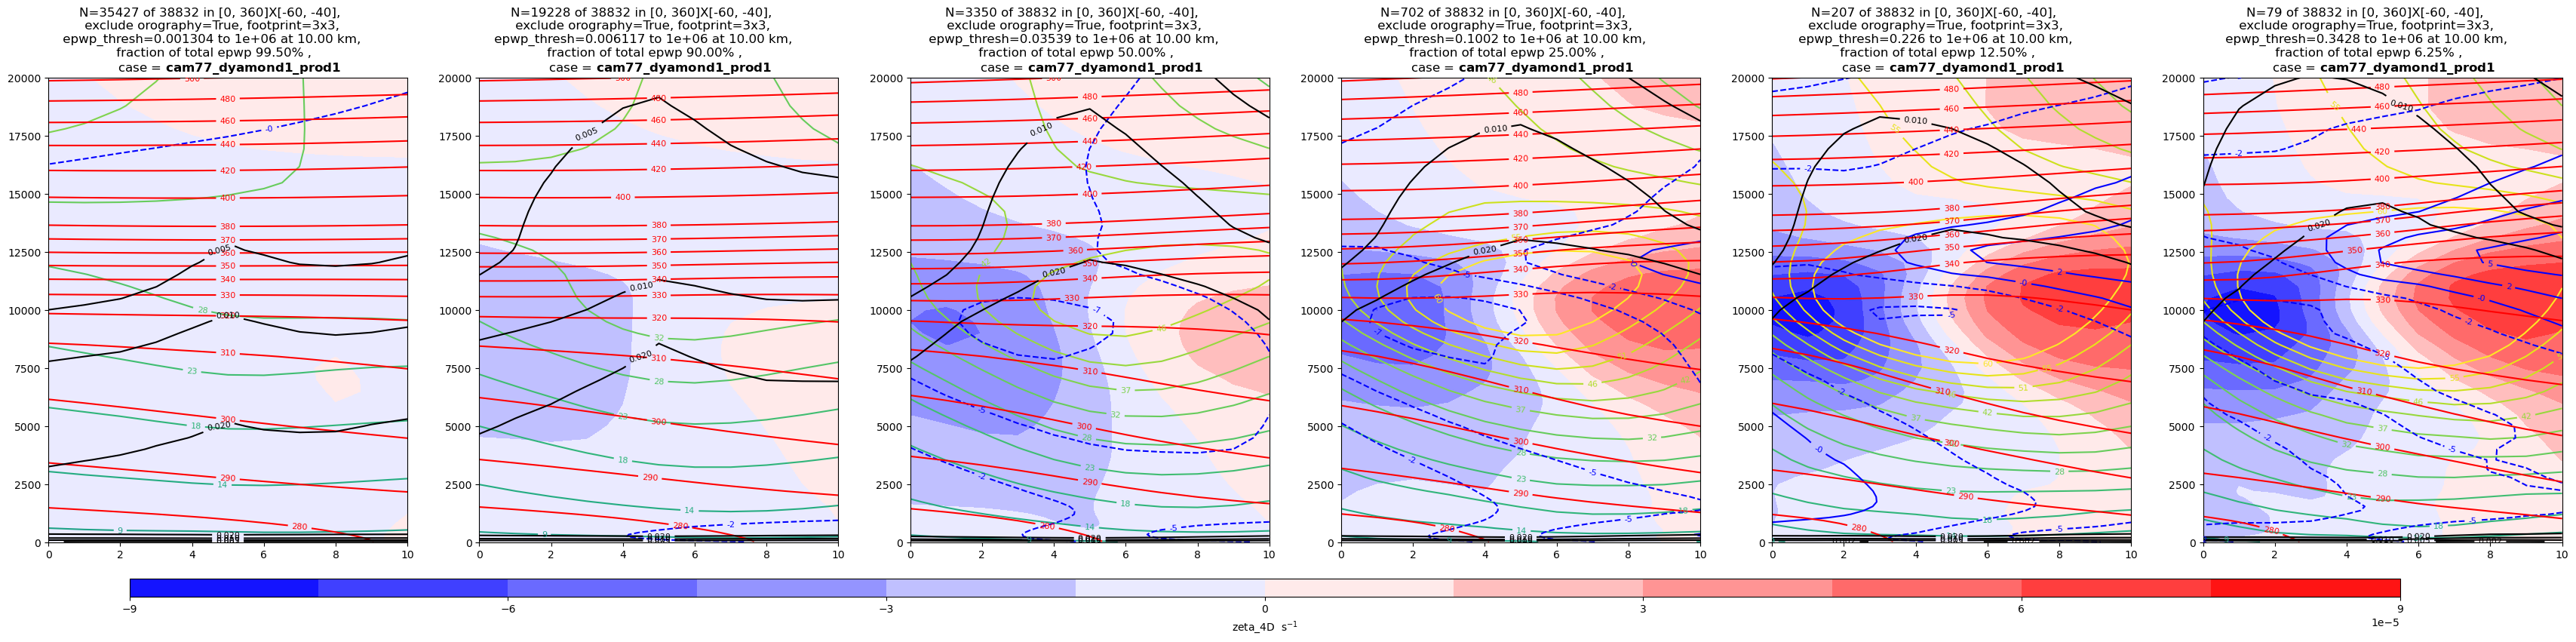

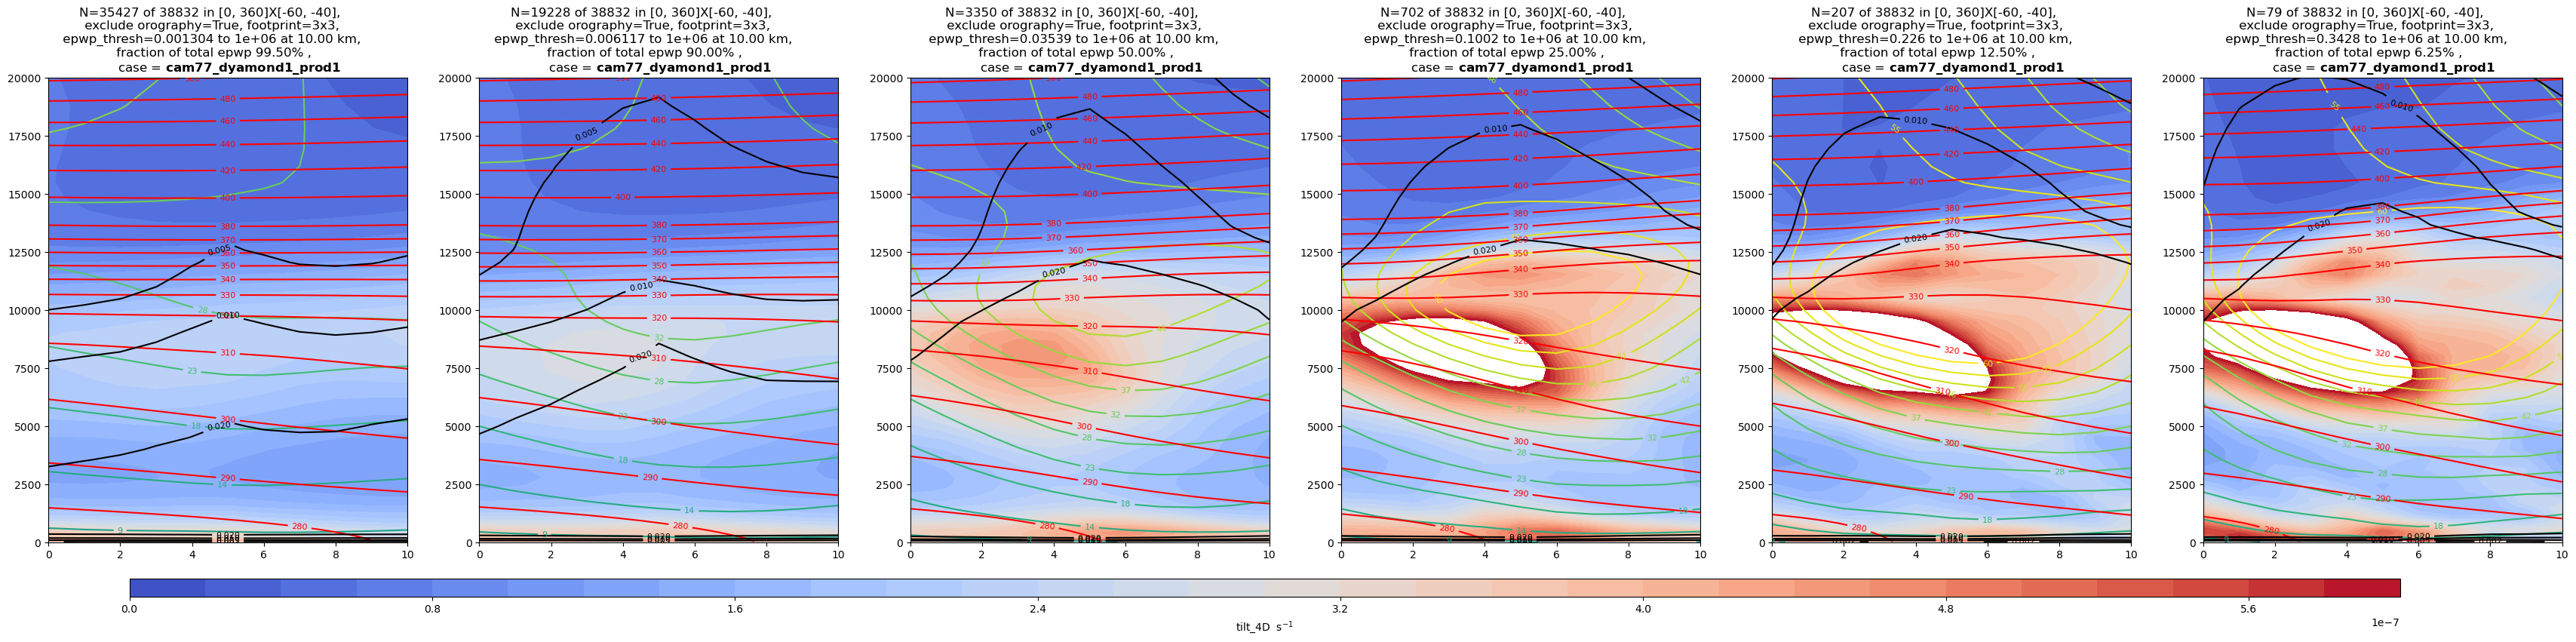

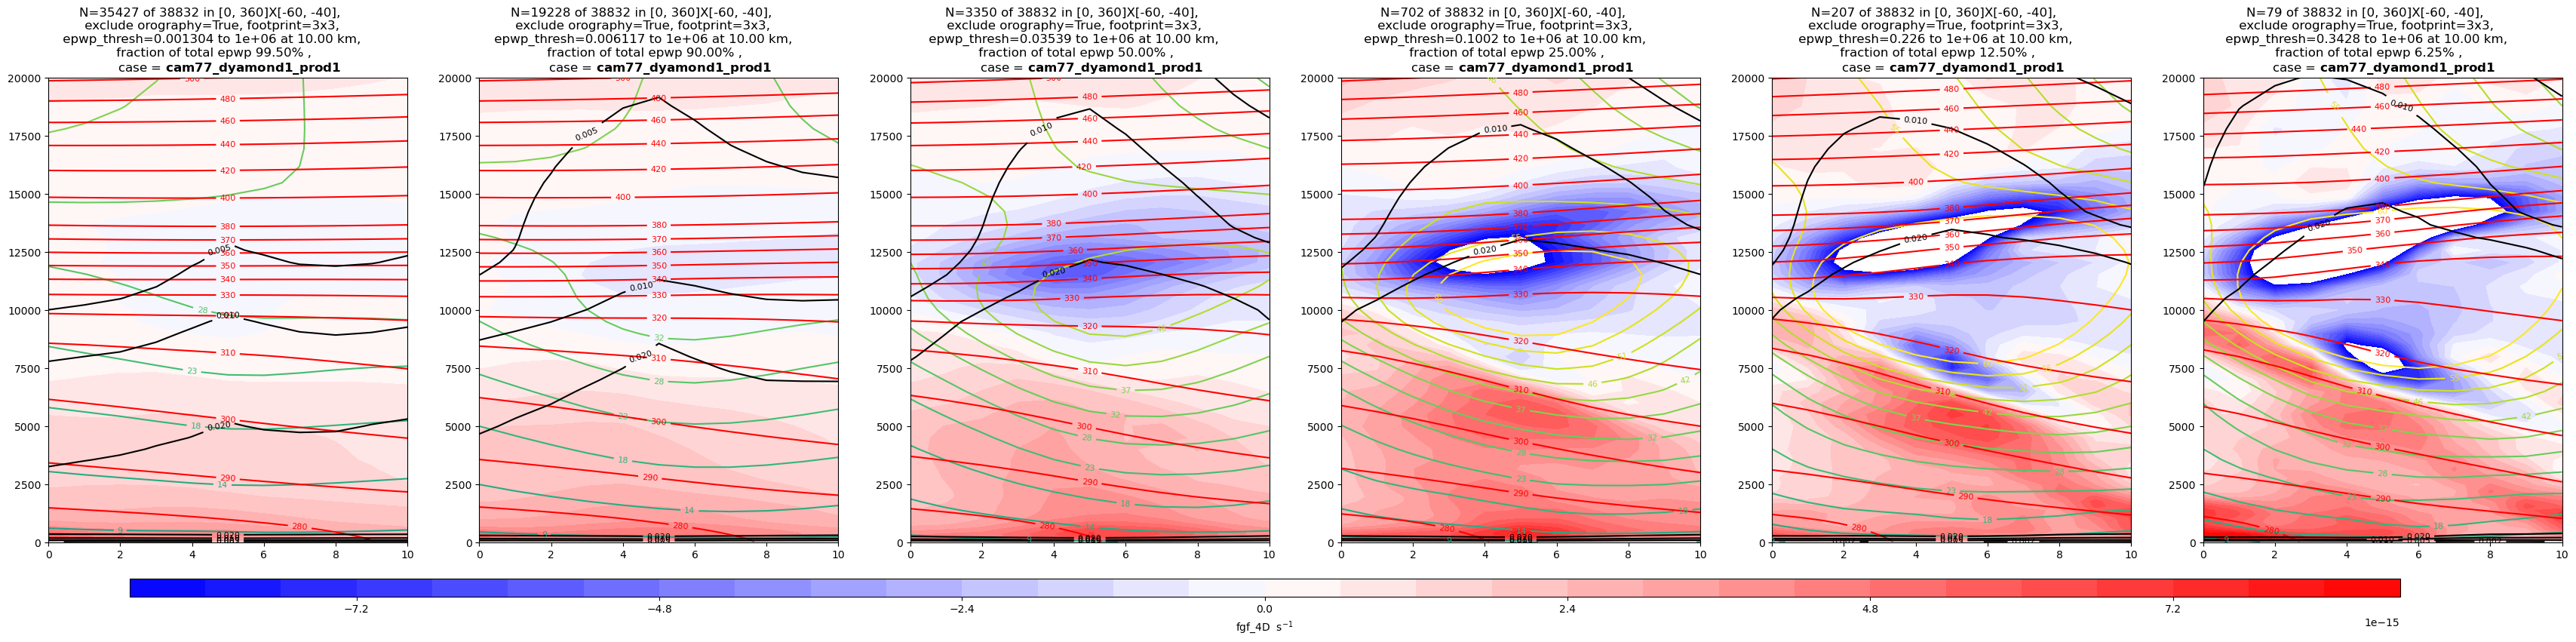

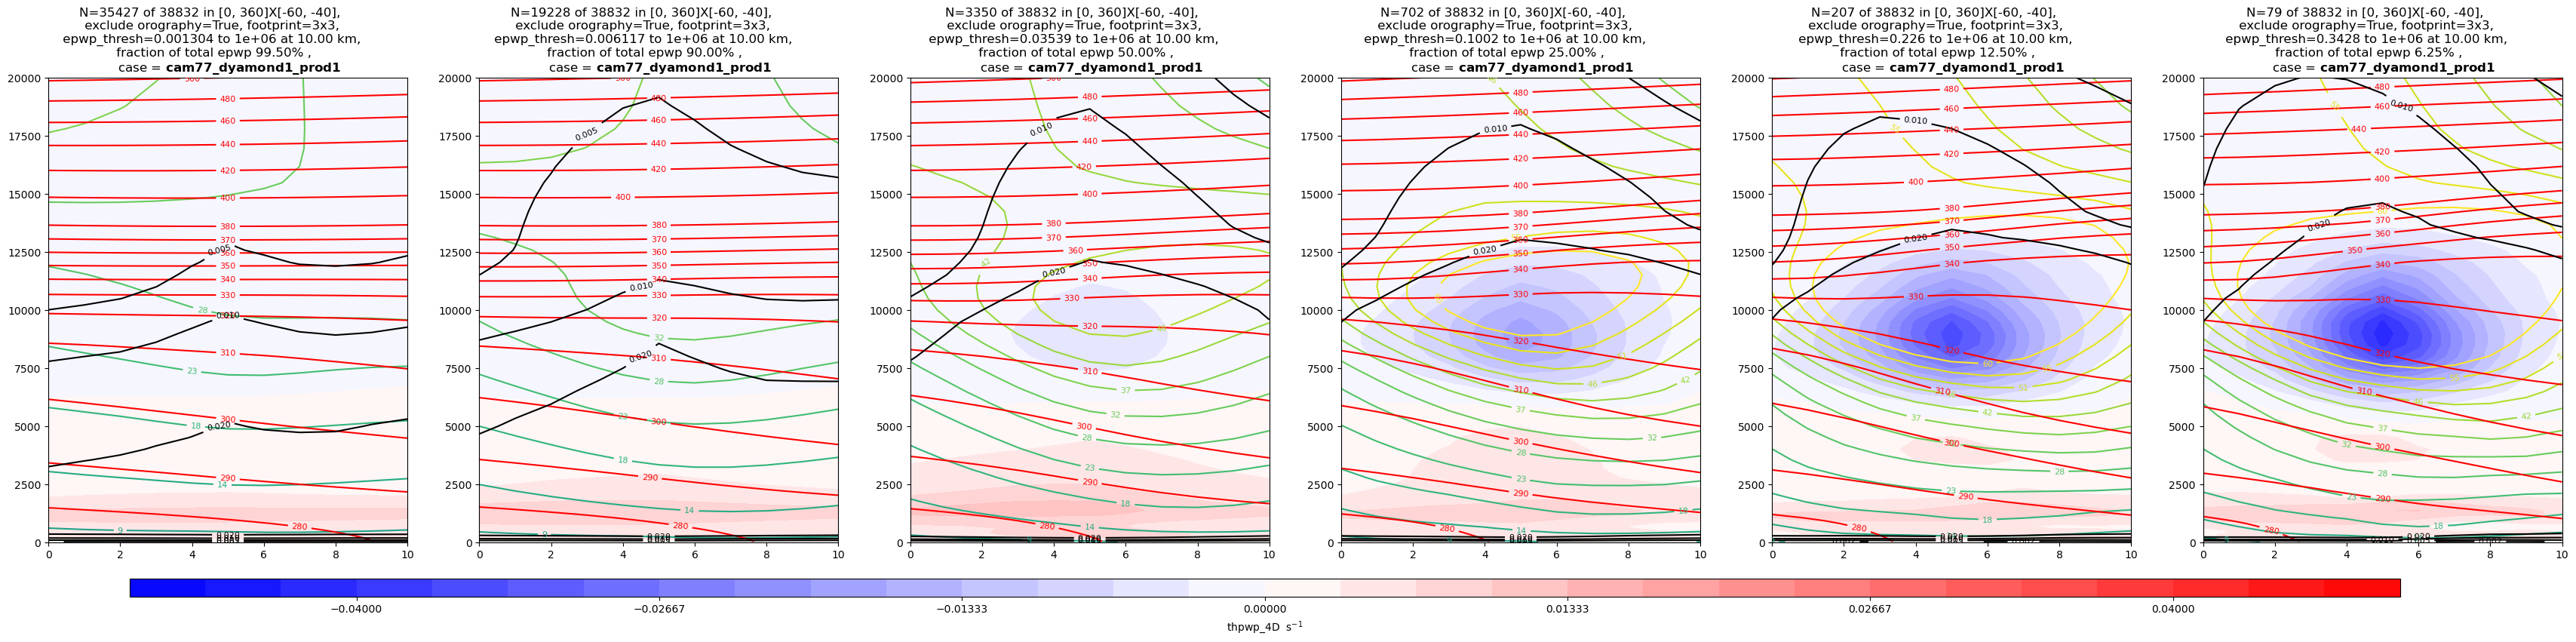

In [11]:
importlib.reload( auti )
auti.plot_xavg_compos( fld='zeta_4D', El=El , plot_v=True )
auti.plot_xavg_compos( fld='tilt_4D', El=El )
auti.plot_xavg_compos( fld='fgf_4D', El=El )
auti.plot_xavg_compos( fld='thpwp_4D', El=El )


[270. 280. 290. 300. 310. 320. 330. 340. 350. 360. 370. 380. 400. 420.
 440. 460. 480. 500. 520. 540. 560. 580.]
[270. 280. 290. 300. 310. 320. 330. 340. 350. 360. 370. 380. 400. 420.
 440. 460. 480. 500. 520. 540. 560. 580.]
[270. 280. 290. 300. 310. 320. 330. 340. 350. 360. 370. 380. 400. 420.
 440. 460. 480. 500. 520. 540. 560. 580.]
[270. 280. 290. 300. 310. 320. 330. 340. 350. 360. 370. 380. 400. 420.
 440. 460. 480. 500. 520. 540. 560. 580.]


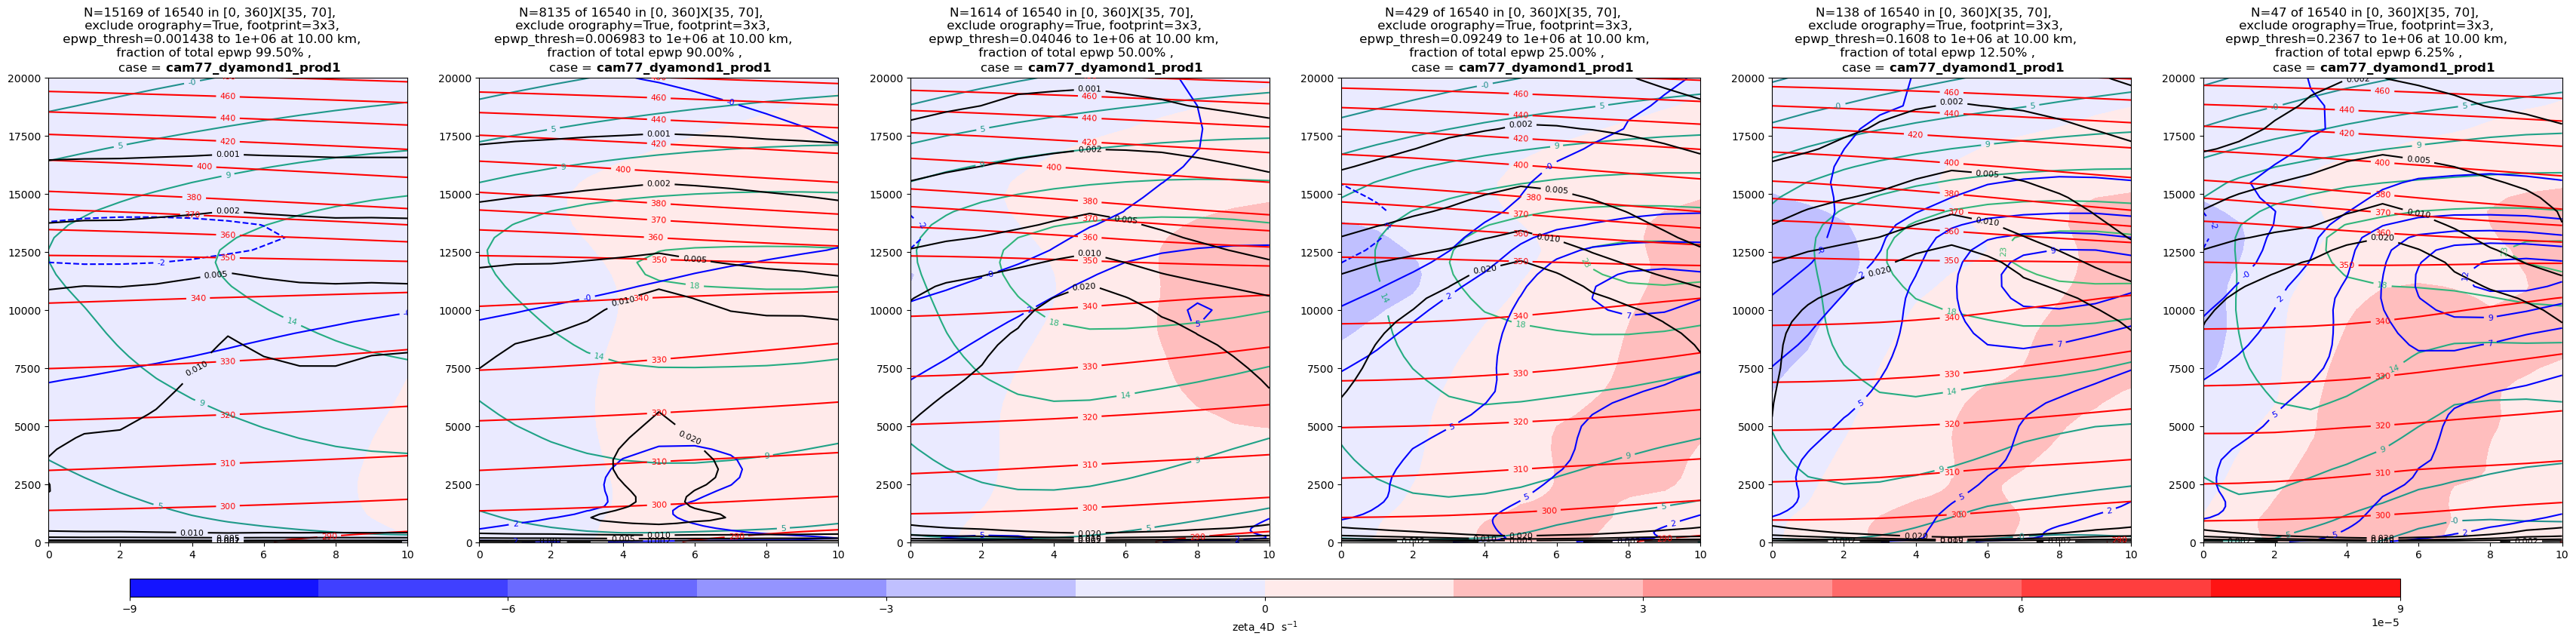

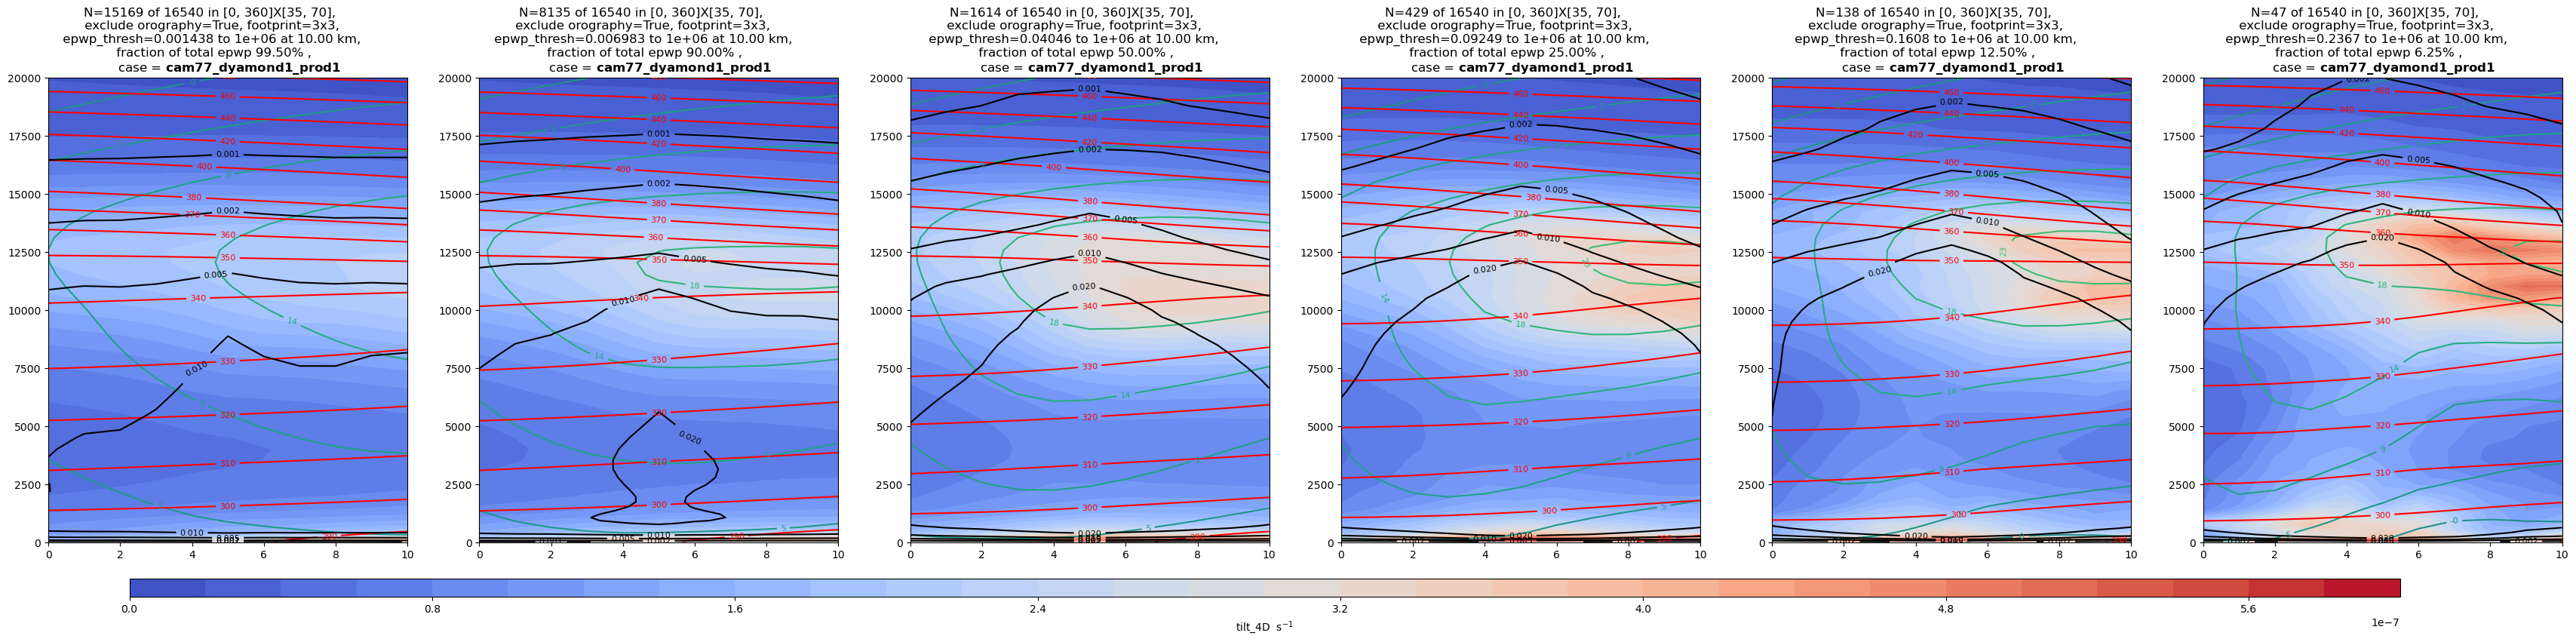

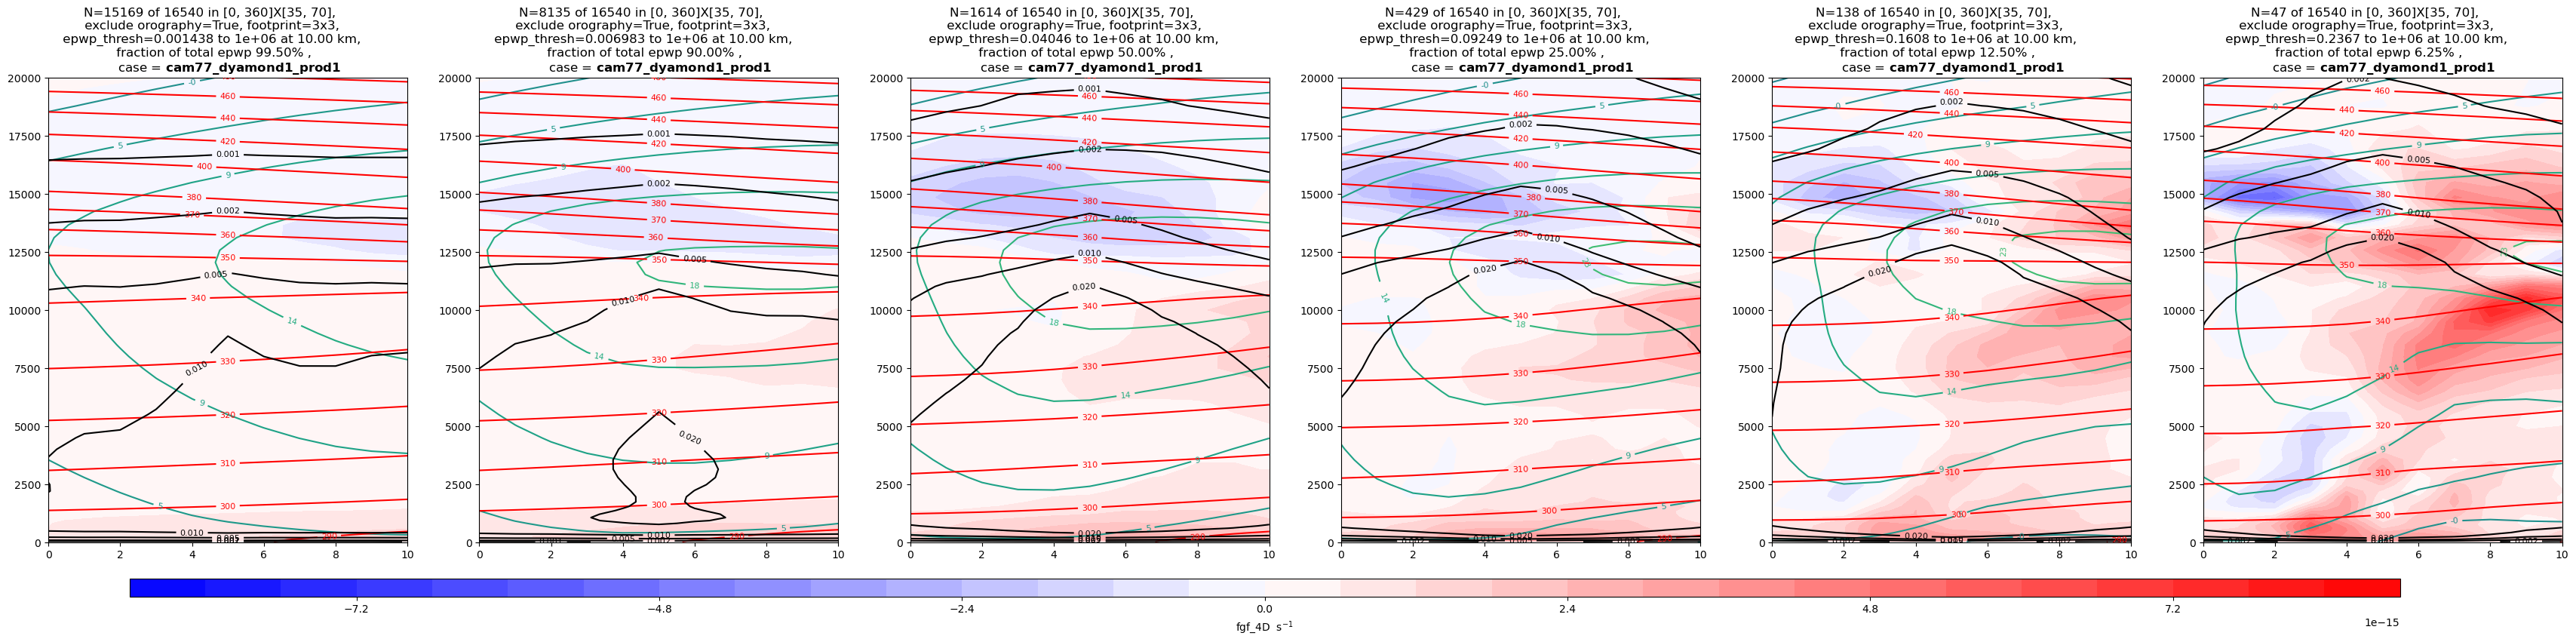

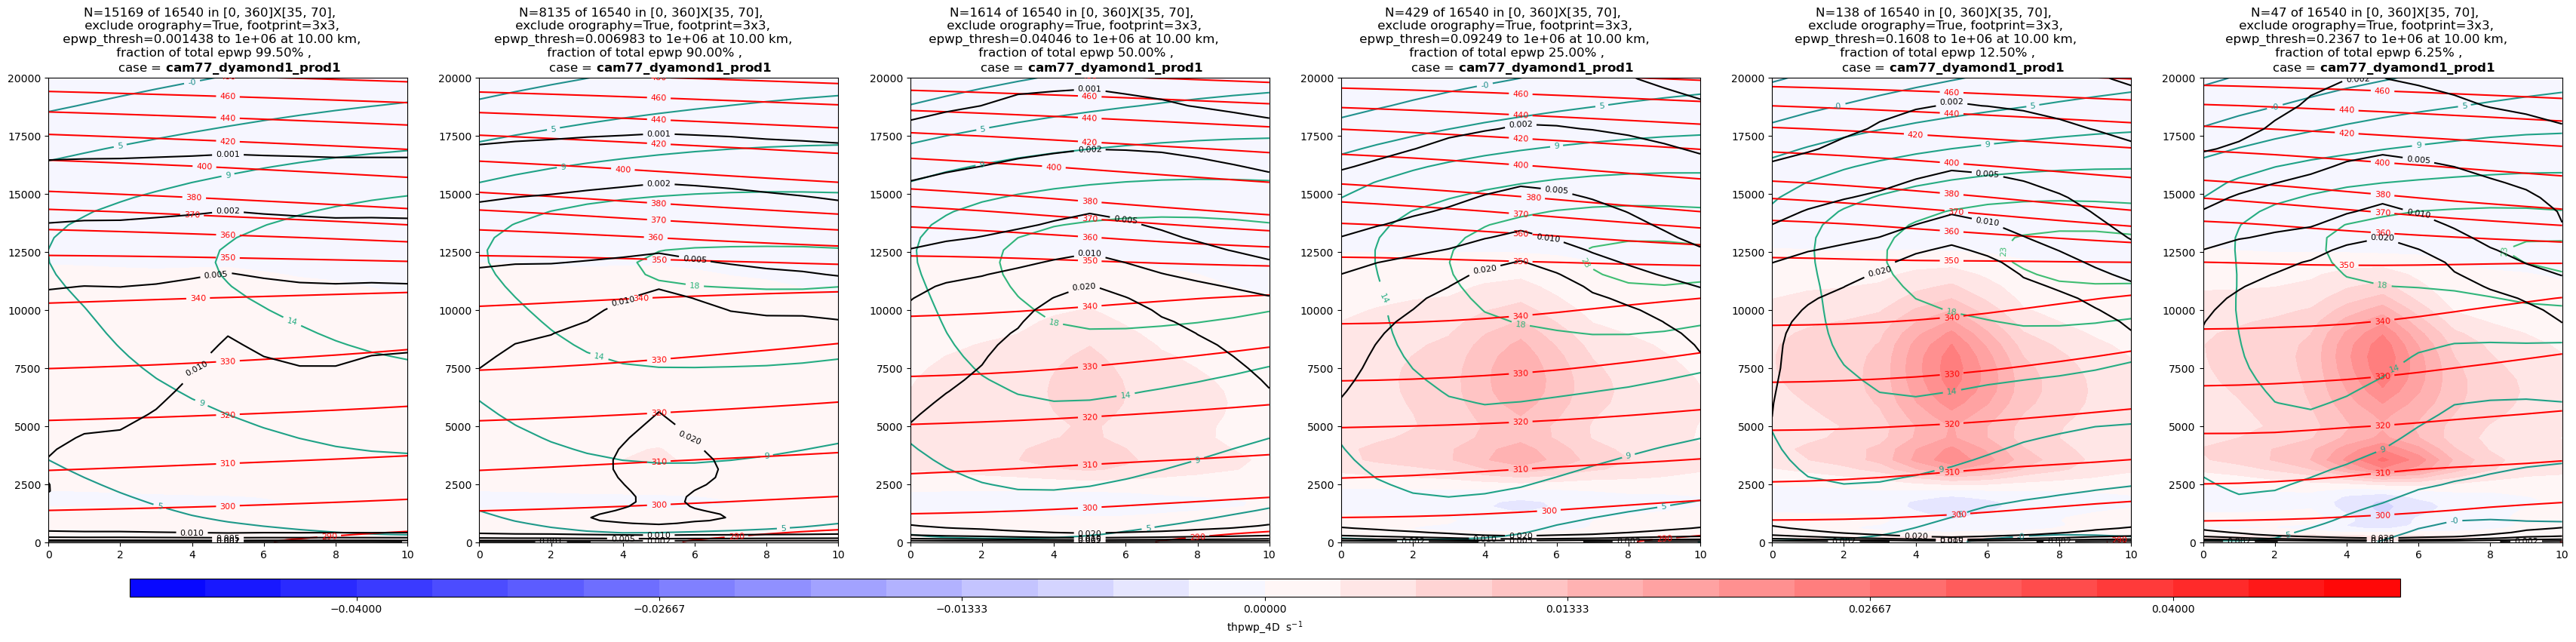

In [12]:
importlib.reload( auti )
auti.plot_xavg_compos( fld='zeta_4D', El=El2, plot_v=True  )
auti.plot_xavg_compos( fld='tilt_4D', El=El2 )
auti.plot_xavg_compos( fld='fgf_4D', El=El2 )
auti.plot_xavg_compos( fld='thpwp_4D', El=El2 )


In [13]:
#import random_forest as RF

Eco=   El[0]  #euti.combine_event_dicts(El[3], El[1], label_key='event_strength')
zlev=El[0].zlevA
z0=np.argmin( np.abs( zlev-0.))
z3=np.argmin( np.abs( zlev-3000.))
z5=np.argmin( np.abs( zlev-5000.))
z6=np.argmin( np.abs( zlev-6000.))
z7=np.argmin( np.abs( zlev-7000.))
z10=np.argmin( np.abs( zlev-10000.))
z11=np.argmin( np.abs( zlev-11000.))
z12=np.argmin( np.abs( zlev-12000.))
z15=np.argmin( np.abs( zlev-15000.))


print( np.shape(Eco.u_4D ))
dt = Eco.timeA[1] - Eco.timeA[0] 
print(dt.total_seconds())

(35427, 4, 58, 11, 11)
10800.0


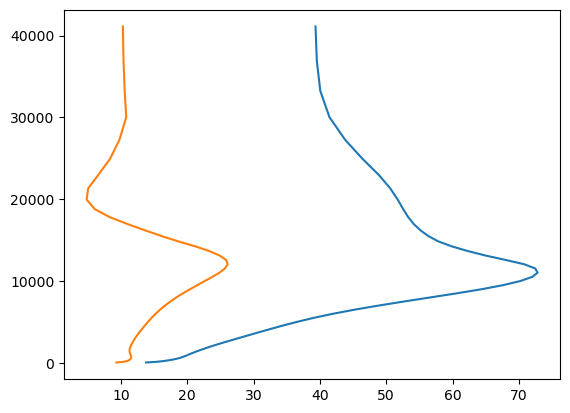

In [14]:
usp = np.sqrt( El[5].u_4D**2 + El[5].v_4D**2 )
usp_v=np.mean( usp[:,-1,:,:,:], axis=(0,2,3) )
usp2 = np.sqrt( El2[5].u_4D**2 + El2[5].v_4D**2 )
usp2_v=np.mean( usp2[:,-1,:,:,:], axis=(0,2,3) )

plt.plot(usp_v,zlev )
plt.plot(usp2_v,zlev )



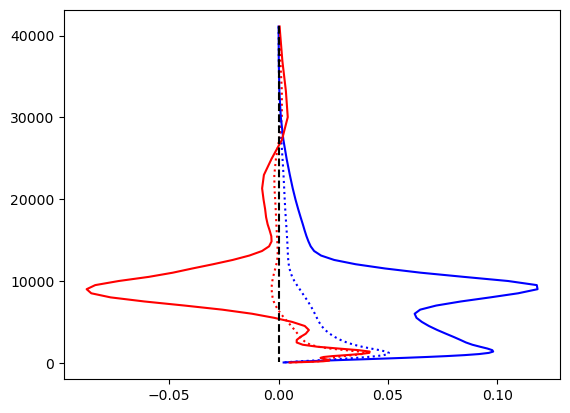

In [15]:
epwp_v=np.mean( El[0].epwp_4D[:,-1,:,:,:], axis=(0,2,3) )
thpwp_v=np.mean( 5*El[0].thpwp_4D[:,-1,:,:,:], axis=(0,2,3) )

plt.plot(epwp_v,zlev,color='blue',linestyle=':' )
plt.plot(thpwp_v,zlev,color='red' , linestyle=':')

epwp_v=np.mean( El[5].epwp_4D[:,-1,:,:,:], axis=(0,2,3) )
thpwp_v=np.mean( 5*El[5].thpwp_4D[:,-1,:,:,:], axis=(0,2,3) )

plt.plot(epwp_v,zlev,color='blue' )
plt.plot(thpwp_v,zlev,color='red' )

plt.plot(0.*zlev,zlev,color='black',linestyle='--'  )




In [16]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
matplotlib.use('module://matplotlib_inline.backend_inline')

In [17]:
Eco.keys()
    

dict_keys(['ds', 'fld', 'case', 'dycore', 'start_date', 'end_date', 'threshold', 'zlev_event', 'exclude_orography', 'lat_range', 'lon_range', 'N_events', 'Total_events', 'Frac_of_total_epwp', 'timeA', 'zlevA', 'latA', 'lonA', 'window_tyx', 'peak_footprint', 'time4D', 'lat4D', 'lon4D', 'u_4D', 'v_4D', 'htopo_4D', 'zeta_4D', 'tilt_4D', 'fgf_4D', 'upwp_4D', 'vpwp_4D', 'epwp_4D', 'th_4D', 'stab_4D', 'precl_4D', 'thpwp_4D'])

aded abs_zeta_4D ot Eco 
Dynamic steering and launch based on tilt_4D
 U_wv_src_mm t=-3, dynamic  , shape = (35427,)  ,minmax=0.030723661786334754 - 36.354027734228985
 U_wv_src_mm t=-2, dynamic  , shape = (35427,)  ,minmax=0.06940487822070265 - 36.94103377261665
 U_wv_src_mm t=-1, dynamic  , shape = (35427,)  ,minmax=0.06940487822070265 - 38.9521437962075
 U_wv_src_mm t=0, dynamic  , shape = (35427,)  ,minmax=0.02568003025358028 - 38.664992320570136
 avg(zeta_4D) t=-3, dynamic z (ZS-ZL avg)  , shape = (35427,) ,minmax=-0.00011757044838169922 - 9.833007782924088e-05
 avg(zeta_4D) t=-3, dynamic z (ZL)  , shape = (35427,) ,minmax=-0.00011443113264946974 - 0.00010582854321515668
 avg(zeta_4D) t=-3, dynamic z (ZS)  , shape = (35427,) ,minmax=-0.00010445845884116955 - 8.707875419949841e-05
 avg(zeta_4D) t=-3, dynamic z (0-ZS avg)  , shape = (35427,) ,minmax=-0.00010593677003212403 - 5.080241520794566e-05
 avg(zeta_4D) t=-2, dynamic z (ZS-ZL avg)  , shape = (35427,) ,minmax=-0.00011757044838

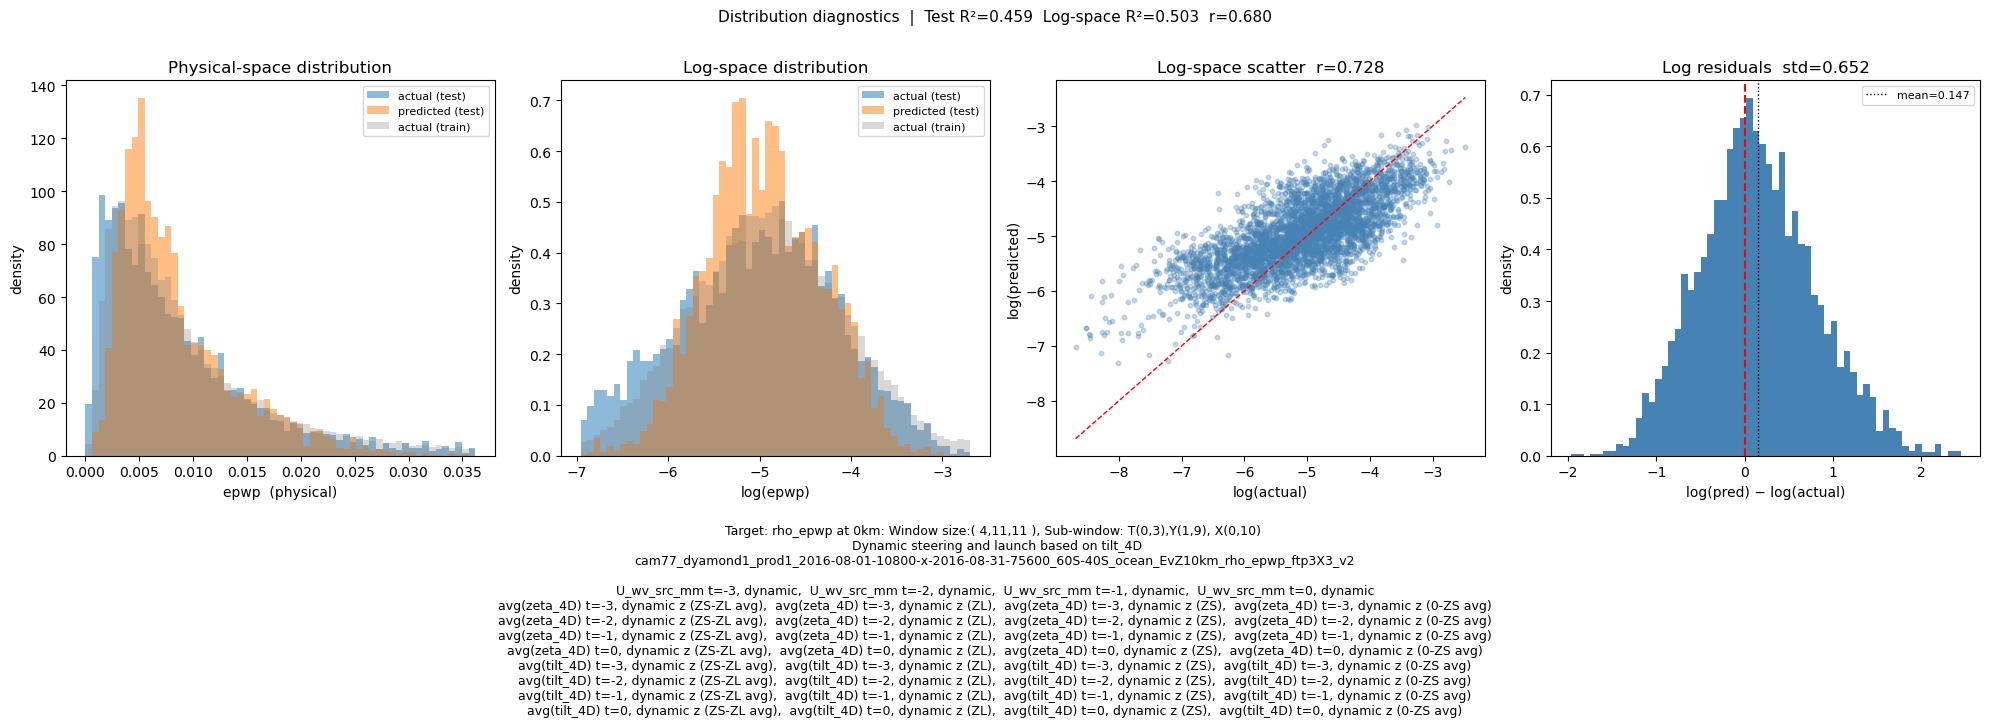

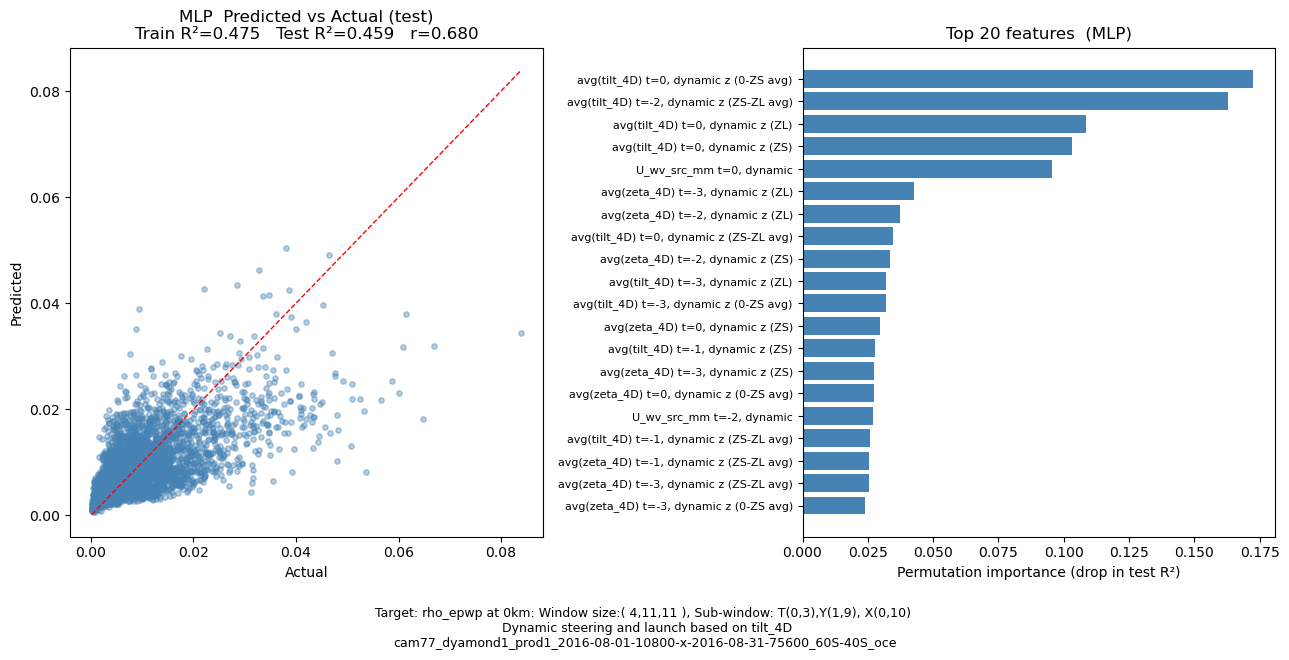

In [19]:
##################
import importlib                                                                                                                                                                                                                                                                                              
import mlp_utils as mlu  
import predictors as Predi
importlib.reload(mlu) 
#importlib.reload(RF)
importlib.reload(Predi)
importlib.reload(eio)


Eco=El[0]
nv,nt_v,nz_v,ny_v,nx_v = np.shape( Eco.epwp_4D )

#Eco['abs_zeta_4D'] = np.abs( Eco['zeta_4D'] )



MyHyperparameters = Predi.reset_hyperparameters()

#And you're now set up to do your lr_patience=15, min_lr=1e-7 experiment cleanly —

"""
MyHyperparameters['predictorSet']    = 'MovMtn-like'
MyHyperparameters['yrange']          = [1, -1]
MyHyperparameters['use_predictors']  = ['tilt_4D','zeta_4D','stab_4D']  #,'u_4D','v_4D']
#MyHyperparameters['use_predictors']  = ['fgf_4D', 'zeta_4D', 'stab_4D']
MyHyperparameters['time_average']    = False
MyHyperparameters['targ_scaling']    = 1.
MyHyperparameters['z_targ']          = z10
MyHyperparameters['lr_patience']     = 3
MyHyperparameters['patience']        = 100
MyHyperparameters['min_lr']          = 1e-6
MyHyperparameters['loss_power']      = 6.0
MyHyperparameters['hidden_dims']     = (8,8) #(16,16)  #(8,8)
MyHyperparameters['z_launch']        = 5_000.
MyHyperparameters['z_steer']        = 1_000.
"""

"""
MyHyperparameters['predictorSet']    = 'GWP-like'
MyHyperparameters['yrange']          = [1, -1]
MyHyperparameters['use_predictors']  = ['tilt_4D', 'zeta_4D', 'stab_4D']  #,'u_4D','v_4D']
#MyHyperparameters['use_predictors']  = ['fgf_4D', 'zeta_4D', 'stab_4D']
MyHyperparameters['time_average']    = True
MyHyperparameters['targ_scaling']    = 1.
MyHyperparameters['z_targ']          = z10
MyHyperparameters['lr_patience']     = 3
MyHyperparameters['patience']        = 100
MyHyperparameters['min_lr']          = 1e-6
MyHyperparameters['loss_power']      = 4.0
MyHyperparameters['hidden_dims']     = (32,32)
"""

"""
MyHyperparameters['predictorSet']    = 'original_default'
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D', 'stab_4D',  'tilt_4D', 'zeta_4D', ] #'fgf_4D',]
MyHyperparameters['use_predictors']  = ['u_4D','v_4D', 'tilt_4D', 'zeta_4D', 'stab_4D',]
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D', 'stab_4D', 'fgf_4D', ]
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D', 'stab_4D', 'tilt_4D', ]
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D', 'stab_4D', 'zeta_4D', ]
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D','tilt_4D', 'zeta_4D', 'stab_4D','fgf_4D']
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D','tilt_4D', 'zeta_4D', 'stab_4D','fgf_4D']
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D', 'stab_4D','fgf_4D']
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D','tilt_4D', 'zeta_4D', 'stab_4D']
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D','th_4D',]
MyHyperparameters['z_targ']          = z10
MyHyperparameters['targ_scaling']    = 1.
MyHyperparameters['yrange']          = [1, -1]
#MyHyperparameters['yrange']          = [3, -3]
#MyHyperparameters['xrange']          = [3, -3]
MyHyperparameters['lr_patience']     = 15
"""

"""
MyHyperparameters['predictorSet']    = 'Probe-steer-launch'
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D', 'stab_4D',  'tilt_4D', 'zeta_4D', ] #'fgf_4D',]
MyHyperparameters['use_predictors']  = ['stab_4D',  'tilt_4D', 'zeta_4D', ] #'fgf_4D',]
#MyHyperparameters['use_predictors']  = ['abs_zeta_4D']
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D', 'stab_4D', 'fgf_4D', ]
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D', 'stab_4D', 'tilt_4D', ]
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D', 'stab_4D', 'zeta_4D', ]
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D','tilt_4D', 'zeta_4D', 'stab_4D','fgf_4D']
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D','tilt_4D', 'zeta_4D', 'stab_4D','fgf_4D']
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D', 'stab_4D','fgf_4D']
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D','tilt_4D', 'zeta_4D', 'stab_4D']
#MyHyperparameters['use_predictors']  = ['u_4D','v_4D','th_4D',]
MyHyperparameters['z_targ']          = z12
MyHyperparameters['targ_scaling']    = 1.
MyHyperparameters['yrange']          = [1, -1]
MyHyperparameters['z_steer']          = [1000,3000,5000,9000]
MyHyperparameters['z_launch']          = [5000,9000,11000]
MyHyperparameters['hidden_dims']     = (16,16)  #(8,8)

#MyHyperparameters['yrange']          = [3, -3]
#MyHyperparameters['xrange']          = [3, -3]
MyHyperparameters['lr_patience']     = 15
"""


MyHyperparameters['predictorSet']    = 'Dynamic-steer-launch'
#MyHyperparameters['use_predictors'] = ['abs_zeta_4D','zeta_4D','tilt_4D']
MyHyperparameters['use_predictors'] = ['tilt_4D','zeta_4D','tilt_4D']
#MyHyperparameters['use_predictors'] = ['vmag_4D','zeta_4D','tilt_4D']
#MyHyperparameters['use_predictors'] = ['abs_zeta_4D','abs_zeta_4D','tilt_4D']
#MyHyperparameters['use_predictors'] = ['tilt_4D','zeta_4D','tilt_4D',]  #'thpwp_4D']
#MyHyperparameters['use_predictors'] = ['tilt_4D','tilt_4D','abs_zeta_4D', ]  #'thpwp_4D']

MyHyperparameters['z_targ']          = -1 #z10
MyHyperparameters['targ_scaling']    = 1.
MyHyperparameters['yrange']          = [1, -1]
MyHyperparameters['trange']          = None #[nt_v-1, nt_v]
MyHyperparameters['hidden_dims']     = (16,16)  #(8,8)

#MyHyperparameters['yrange']          = [3, -3]
#MyHyperparameters['xrange']          = [3, -3]
MyHyperparameters['lr_patience']     = 15


predictors, predictor_names, use_predictors, key_z, short_desc, yv = \
    Predi.build_predictor_set(Eco, zlev, MyHyperparameters)

mlp_model, mlp_results = mlu.fit_mlp_general(
    predictors      = predictors,
    predictor_names = predictor_names,
    target          = yv,
    event_times     = Eco.time4D,
    train_interval  = (48, 248),
    test_interval   = (0, 28),
    **{k: MyHyperparameters[k] for k in [
        'hidden_dims', 'dropout', 'batch_size', 'lr',
        'weight_decay', 'patience', 'max_epochs',
        'lr_patience', 'lr_factor', 'min_lr',
        'loss_power', 'log_predictor_patterns',
    ]}
)




mlu.plot_distributions(mlp_results, desc=short_desc  ) 

mlu.plot_mlp_results(mlp_results, top_n=20 ,desc=short_desc[0:200])


In [20]:

meta = {
    'feat_scaler':   mlp_results['feat_scaler'],
    'target_scaler': mlp_results['target_scaler'],
    'log_pred_mask': mlp_results['log_pred_mask'],
}
device = 'cpu'  # or 'cuda' if you're on GPU

In [21]:
######### TRANSFER LEARNING ????????  #################################################
from scipy import stats


Eco2 = El2[0]
Eco2['abs_zeta_4D'] = np.abs( Eco2['zeta_4D'] )

predictors_2, predictor_names, use_predictors, key_z, short_desc, yv_2 = \
    Predi.build_predictor_set(Eco2, zlev, MyHyperparameters)



################################

y_pred_2 = mlu.apply_mlp(mlp_model, meta, device, predictors_2)


print(y_pred_2.shape)
print(yv_2.shape)



eps = 1e-12
ly_pred_2       = np.log(np.maximum(y_pred_2,  eps))
ly_targ_2       = np.log(np.maximum(yv_2        ,  eps))
r_log, _ = stats.pearsonr(ly_targ_2, ly_pred_2)
print(r_log )

Dynamic steering and launch based on tilt_4D
 U_wv_src_mm t=-3, dynamic  , shape = (15169,)  ,minmax=0.09313612691601243 - 30.794233843718764
 U_wv_src_mm t=-2, dynamic  , shape = (15169,)  ,minmax=0.058147131168008966 - 29.82529894157247
 U_wv_src_mm t=-1, dynamic  , shape = (15169,)  ,minmax=0.06821929699213107 - 29.01796535661219
 U_wv_src_mm t=0, dynamic  , shape = (15169,)  ,minmax=0.06417338548248826 - 31.088381057134615
 avg(zeta_4D) t=-3, dynamic z (ZS-ZL avg)  , shape = (15169,) ,minmax=-7.290212643021127e-05 - 0.00010852125069995392
 avg(zeta_4D) t=-3, dynamic z (ZL)  , shape = (15169,) ,minmax=-9.37013908888019e-05 - 0.00011631245874633254
 avg(zeta_4D) t=-3, dynamic z (ZS)  , shape = (15169,) ,minmax=-5.398091184238971e-05 - 9.896389482834576e-05
 avg(zeta_4D) t=-3, dynamic z (0-ZS avg)  , shape = (15169,) ,minmax=-3.628118602420667e-05 - 7.549034840979187e-05
 avg(zeta_4D) t=-2, dynamic z (ZS-ZL avg)  , shape = (15169,) ,minmax=-6.816401718811345e-05 - 0.000110911149887772

Text(0.5, -0.02, 'Target: rho_epwp at 0km: Window size:( 4,11,11 ), Sub-window: T(0,3),Y(1,9), X(0,10) \n Dynamic steering and launch based on tilt_4D\ncam77_dyamond1_prod1_2016-08-01-10800-x-2016-08-')

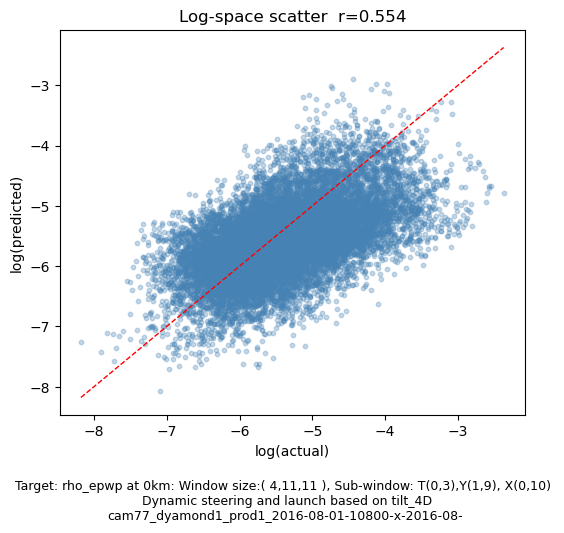

In [22]:
fig, axes = plt.subplots(1, 1, figsize=(6, 5))

# --- panel 1: log-log scatter ---
ax = axes
ax.scatter(ly_targ_2, ly_pred_2, alpha=0.3, s=10, color='steelblue')
lims = [min(ly_targ_2.min(), ly_pred_2.min()),
        max(ly_targ_2.max(), ly_pred_2.max())]
ax.plot(lims, lims, 'r--', lw=1)
r_log, _ = stats.pearsonr(ly_targ_2, ly_pred_2)
ax.set_xlabel('log(actual)')
ax.set_ylabel('log(predicted)')
ax.set_title(f'Log-space scatter  r={r_log:.3f}')

ax.text(0.5, -0.02, short_desc[0:180], ha='center', va='top', fontsize=9,
         transform=fig.transFigure)



In [ ]:
print( El[0].u_4D.shape )

In [ ]:
importlib.reload( auti )

plev=100_000. * np.exp( -zlev / 7000. )

fig,axs=plt.subplots( 1, 2 , figsize =( 17,6) )
i=0
u=3
for Eco in [ El2[u] , El[u] ]:
    
    #zoop = np.mean( Eco.zeta_4D[:,-1,:,:,:]  , axis=(2,3) )
    #zoop = np.mean( Eco.tilt_4D[:,-1,:,:,:]  , axis=(2,3) )
    zoop = np.mean( np.sqrt( Eco.u_4D[:,-1,:,:,:]**2  + Eco.v_4D[:,-1,:,:,:]**2  )  , axis=(2,3) )
    
    ncol,nz = np.shape(zoop)
    
    pmid = np.tile( plev , (ncol,1) )

    steering_level, launch_level, c_steer, c_launch = auti.vorticity_centroid_levels(vorticity = zoop , coord=pmid , bound_surface=85_000., bound_top=5_000. )

    ax=axs[i] 
    ax.contourf( np.arange( ncol) , plev, zoop.T )
    ax.plot( np.arange( ncol) , c_steer ,color='black' , alpha=1. )
    ax.plot( np.arange( ncol) , c_launch ,color='black' , linestyle='--' ,alpha=1.)
    i=i+1

In [ ]:
importlib.reload( Predi )

#zoop2,zs,zl,plev_s,plev_l = Predi.dynamic_steer_launch(Eco=El[3],zlev=zlev ) 
predictors,predictor_names,use_predictors,key_z,short_desc,zs,zl     = Predi.dynamic_steer_launch(Eco=El[3],zlev=zlev , verbose=True , debug=True ) 



In [ ]:

u=6
print(predictor_names[u] )
zuzu=predictors[u]
print(zuzu.shape)



v,t=90,2
pred_='tilt_4D'
zs0,zl0 = zs[v,t] , zl[v,t] 
predo = np.mean( El[3][pred_][v,t,zl0:zs0,:,:], axis=(0,1,2))
pred_='zeta_4D'
predo2 = np.mean( np.abs(El[3][pred_])[v,t,zl0:zs0,:,:], axis=(0,1,2))


print(f"here {predo}")
print(f"zuzu {zuzu[v]}")

print( " " )
print(f"here {predo2}")
print(f"zuzu {zuzu[v]}")



In [ ]:
uu=np.mean( El[3].u_4D , axis=(3,4) )
vv=np.mean( El[3].v_4D , axis=(3,4) )

v,t = 10,-1

print( uu[v,t,  zs[v,t] ] )
print( u_steer[v] )
print( vv[v,t,  zs[v,t] ] )
print( v_steer[v] )

print( uu[v,t,  zl[v,t] ] - u_steer[v] )
print( u_lnch[v] )
print( vv[v,t,  zl[v,t] ]  - v_steer[v])
print( v_lnch[v] )



In [ ]:
Eco=El[3]
t=-1
print( type(zs[0]) )
u_steer=np.mean(Eco['u_4D'][:,t, zs.astype(int) ,:,:], axis=(1,2))


In [ ]:
u_steer.shape

In [ ]:
fig,axs=plt.subplots( 1, 2 , figsize =( 17,6) )
ax=axs[0]
ax.plot( plev_s[:,-1] )
ax.plot( c_steer )
ax=axs[1]
ax.plot( zoop2[:,-1,40] )
ax.plot( zoop[:,40] )



In [ ]:
#########################################
import mlp_to_pptx
importlib.reload(mlp_to_pptx)
case_name='A_3rd_test'
mlp_to_pptx.export_mlp_pptx(
    mlp_results     = mlp_results,
    hyperparameters = MyHyperparameters,
    case_name       = case_name,
    pptx_out        = f"/glade/work/juliob/HiRes_ana_dev/Drivers/Analysis/{case_name}.pptx",
    transfer_results = {
        'y_pred' : y_pred_2,
        'y_targ' : yv_2,
        'label'  : 'NH transfer (El2)',
    },
)

In [ ]:
print( El[0].threshold )
print( np.log( El[0].threshold ))


In [ ]:
print( stop_here )

In [ ]:



El[bb].tilt_4D.shape

In [ ]:
fig,axs=plt.subplots( 1 , 4, figsize=(21,5)  )

bb=5
p=0
ax=axs[p]
ax.plot( np.mean( El[bb].tilt_4D, axis=(0,1,3,4) ) , zlev )
ax.plot( np.mean( El2[bb].tilt_4D, axis=(0,1,3,4) ) , zlev )
ax.set_ylim( 0,20_000 )
p=p+1
ax=axs[p]
ax.plot( np.mean( El[bb].zeta_4D, axis=(0,1,3,4) ) , zlev )
ax.plot( np.mean( El2[bb].zeta_4D, axis=(0,1,3,4) ) , zlev )
ax.set_ylim( 0,20_000 )
p=p+1
ax=axs[p]
ax.plot( np.mean( El[bb].u_4D, axis=(0,1,3,4) ) , zlev, color='blue' )
ax.plot( np.mean( El[bb].v_4D, axis=(0,1,3,4) ) , zlev, linestyle='--',color='blue' )

ax.plot( np.mean( El2[bb].u_4D, axis=(0,1,3,4) ) , zlev, color='orange' )
ax.plot( np.mean( El2[bb].v_4D, axis=(0,1,3,4) ) , zlev, linestyle='--',color='orange' )
ax.set_ylim( 0,20_000 )
p=p+1
ax=axs[p]
ax.plot( np.mean( El[bb].th_4D, axis=(0,1,3,4) ) , zlev )
ax.plot( np.mean( El2[bb].th_4D, axis=(0,1,3,4) ) , zlev )
ax.set_ylim( 0,20_000 )


In [ ]:
fig,axs=plt.subplots( 1 , 4, figsize=(21,5)  )

bb=0
p=0
ax=axs[p]
ax.plot( np.mean( El[bb].tilt_4D, axis=(0,1,3,4) ) , zlev )
ax.plot( np.mean( El2[bb].tilt_4D, axis=(0,1,3,4) ) , zlev )
ax.set_ylim( 0,20_000 )
p=p+1
ax=axs[p]
ax.plot( np.mean( El[bb].zeta_4D, axis=(0,1,3,4) ) , zlev )
ax.plot( np.mean( El2[bb].zeta_4D, axis=(0,1,3,4) ) , zlev )
ax.set_ylim( 0,20_000 )
p=p+1
ax=axs[p]
ax.plot( np.mean( El[bb].u_4D, axis=(0,1,3,4) ) , zlev, color='blue' )
ax.plot( np.mean( El[bb].v_4D, axis=(0,1,3,4) ) , zlev, linestyle='--',color='blue' )

ax.plot( np.mean( El2[bb].u_4D, axis=(0,1,3,4) ) , zlev, color='orange' )
ax.plot( np.mean( El2[bb].v_4D, axis=(0,1,3,4) ) , zlev, linestyle='--',color='orange' )
ax.set_ylim( 0,20_000 )
p=p+1
ax=axs[p]
ax.plot( np.mean( El[bb].th_4D, axis=(0,1,3,4) ) , zlev )
ax.plot( np.mean( El2[bb].th_4D, axis=(0,1,3,4) ) , zlev )
ax.set_ylim( 0,20_000 )


In [ ]:
plev = 100_000.* np.exp( -zlev / 7_000. )
zetooo= np.abs(np.mean( El[bb].zeta_4D, axis=(0,1,3,4) ))**2

p_steer = np.sum( zetooo*plev ) /np.sum( zetooo) 
z_steer = -7_000.*np.log( p_steer/100_000. )
print( f"{p_steer} Pa/ {z_steer} m")


In [ ]:
importlib.reload( auti )
auti.plot_xavg_compos( fld='zeta_4D', El=El )
auti.plot_xavg_compos( fld='tilt_4D', El=El )
auti.plot_xavg_compos( fld='fgf_4D', El=El )
auti.plot_xavg_compos( fld='thpwp_4D', El=El )


In [ ]:
importlib.reload( auti )
auti.plot_xavg_compos( fld='zeta_4D', El=El2 )
auti.plot_xavg_compos( fld='tilt_4D', El=El2 )
auti.plot_xavg_compos( fld='fgf_4D', El=El2 )
auti.plot_xavg_compos( fld='thpwp_4D', El=El2 )


In [ ]:
El2[4].tilt_4D.shape

In [ ]:

#plev, pilev = 100_000. * np.exp( -El[0].zlevA / 7_000. ) , 100_000. * np.exp( -A.zilev / 7_000. ) 
plev = 100_000. * np.exp( -El[0].zlevA / 7_000. ) 

zlev = El[0].zlevA
plt.plot( plev )

In [ ]:
A.tilt.shape


In [ ]:
importlib.reload( auti )
Epo=El[5]
wgt = np.abs( Epo.zeta_4D[:,3,:,5,5] )
p_cent = auti.compute_weighted_centroid(w=wgt, z=plev, z_min=0.,z_max=80_000.)


plt.plot( p_cent )

In [ ]:
z1=np.argmin( np.abs( zlev-1000.))
z2=np.argmin( np.abs( zlev-2000.))
z7=np.argmin( np.abs( zlev-7000.))
z8=np.argmin( np.abs( zlev-8000.))
z9=np.argmin( np.abs( zlev-9000.))



z_maxs = np.zeros( np.shape(Epo.u_4D)[0] , dtype=int) 
p_top  = np.zeros( np.shape(Epo.u_4D)[0] , dtype=int) 
for n in np.arange( np.shape(Epo.u_4D)[0] ):
    fo = np.abs( Epo.tilt_4D[n,3,:,5,5] )
    fo[z_cent[n]:]=0.
    p_top[n] = auti.compute_weighted_centroid(w=fo, z=plev, z_min=0.,z_max=80_000.)
    f = fo # auti.smooth_z( fo, zlev, wz=3_000. )
    z_maxs[n] = int(np.argmax( f ))

#z_maxs
fig,axs = plt.subplots(1,4, figsize=(30,8) )
ax=axs[0]
ax.plot( plev[ z_maxs ] , 'o' )
ax.plot( p_cent , '+' )
ax=axs[1]
ax.plot( p_cent - plev[ z_maxs ] , '-o' )
ax=axs[2]
ax.plot( p_top , 'o' )
ax.plot( p_cent , '+' )
ax=axs[3]
ax.plot( p_cent - p_top , '-o' )

#ax.scatter( p_cent - plev[ z_maxs ] ,Epo.tilt_4D[n,3,z_maxs,5,5])
#ax.plot( p_cent , '+' )
#plt.xlim(15,25 )

In [ ]:
importlib.reload( auti )
Epo=El[5]
wgt = np.abs( Epo.tilt_4D[:,3,:,5,5] )
p_cent = auti.compute_weighted_centroid(w=wgt, z=plev, z_min=0.,z_max=80_000.)

z_cent = np.zeros( len(p_cent) , dtype=int ) 
for i in np.arange( len(p_cent)):
    z_cent[i] = np.argmin( np.abs( p_cent[i]-plev) )


z_maxs = np.zeros( np.shape(Epo.u_4D)[0] , dtype=int) 
p_top  = np.zeros( np.shape(Epo.u_4D)[0] , dtype=int) 
for n in np.arange( np.shape(Epo.u_4D)[0] ):
    fo = np.abs( Epo.tilt_4D[n,3,:,5,5] )
    fo[z_cent[n]:]=0.
    p_top[n] = auti.compute_weighted_centroid(w=fo, z=plev, z_min=0.,z_max=80_000.)

#z_maxs
fig,axs = plt.subplots(1,2, figsize=(15,8) )
ax=axs[0]
ax.plot( p_top , 'o' )
ax.plot( p_cent , '+' )
ax=axs[1]
ax.plot( p_cent - p_top , '-o' )


In [ ]:
for n in np.arange( np.shape(Epo.u_4D)[0] ):
    fo = np.abs( Epo.tilt_4D[n,3,:,5,5] )
    fo[z2:]=0.
    f = auti.smooth_z( fo, zlev, wz=3_000. )
    plt.plot( f, plev, color='blue' , alpha=0.2 )

plt.ylim(100_000, 0)

In [ ]:
for n in np.arange( np.shape(Epo.u_4D)[0] ):
    fo = np.abs( Epo.tilt_4D[n,3,:,5,5] )
    f = auti.smooth_z( fo, zlev, wz=1_000. )
    plt.plot( f , zlev, color='blue' , alpha=0.2 )

plt.ylim(00,20_000)

In [ ]:
%%time

importlib.reload( auti )
wgt = np.moveaxis(A.tilt, 1, -1)              # (nt, ny, nx, nz)
p_cent_tyx = auti.compute_weighted_centroid(wgt, plev, z_max=95_000.)   # already (nt, ny, nx), no reshape needed

p_cent_tyx.shape

In [ ]:
plt.contourf( np.mean(p_cent_tyx[:,:,:], axis=0 ) )
plt.colorbar()

In [ ]:
print(f"{El[5].threshold[0]:.4f}-{El[5].threshold[1]:.4g}".replace('.','_').replace('+','') )

In [ ]:
importlib.reload(eio)

eio.write_event_ds(El=El)